In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tensorflow.keras.datasets import mnist

In [2]:
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

11490434/11490434 [==============================] - 0s 0us/step


In [3]:
train_images.shape

(60000, 28, 28)

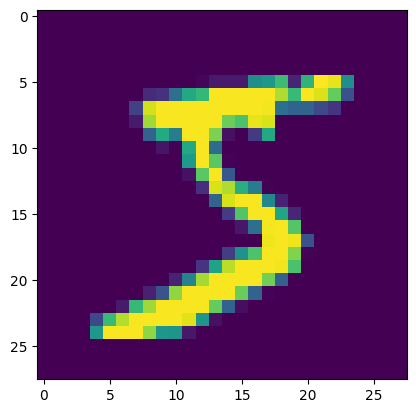

In [4]:
plt.imshow(train_images[0])

In [5]:
train_labels[0]

5

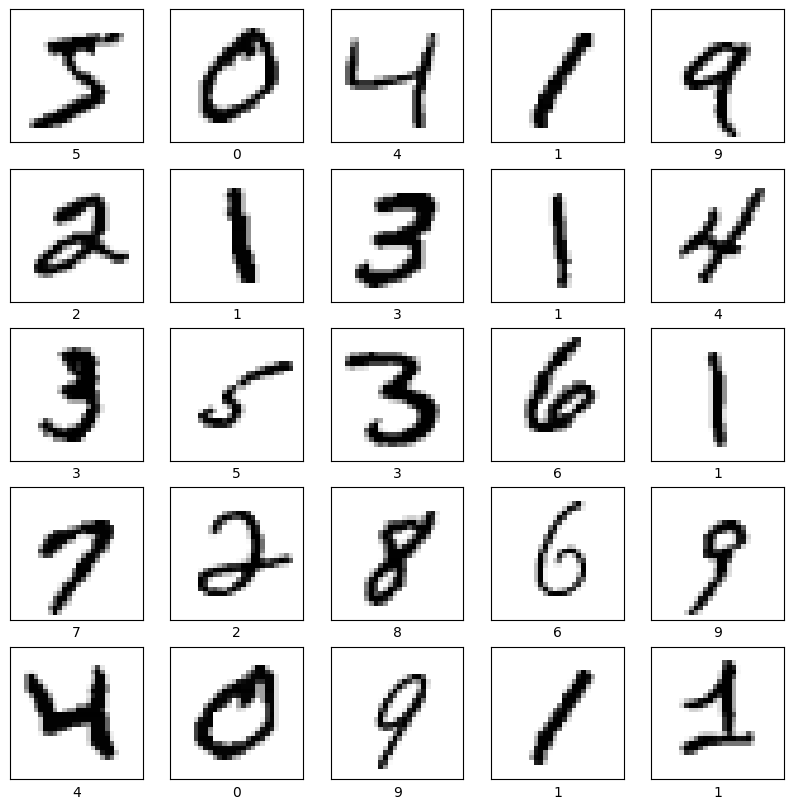

In [6]:
class_names = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']

plt.figure(figsize=(10,10))
for i in range(25):
  plt.subplot(5,5,i+1)
  plt.xticks([])
  plt.yticks([])
  plt.grid(False)
  plt.imshow(train_images[i], cmap=plt.cm.binary)
  plt.xlabel(class_names[train_labels[i]])
plt.show()

In [7]:
train_images = train_images / 255.0
test_images = test_images / 255.0

In [8]:
base_model_mnist = tf.keras.Sequential([
  tf.keras.layers.Flatten(input_shape=(28, 28)),
  tf.keras.layers.Dense(6, activation='relu'),
  tf.keras.layers.Dense(6, activation='relu'),
  tf.keras.layers.Dense(10, activation='softmax')
])

base_model_mnist.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

base_model_mnist_loss = base_model_mnist.fit(train_images, train_labels, epochs=20, validation_data=(test_images, test_labels))

Epoch 1/20
1875/1875 [==============================] - 9s 4ms/step - loss: 0.8540 - accuracy: 0.7201 - val_loss: 0.4782 - val_accuracy: 0.8661
Epoch 2/20
1875/1875 [==============================] - 5s 3ms/step - loss: 0.4368 - accuracy: 0.8745 - val_loss: 0.4029 - val_accuracy: 0.8829
Epoch 3/20
1875/1875 [==============================] - 6s 3ms/step - loss: 0.3893 - accuracy: 0.8875 - val_loss: 0.3741 - val_accuracy: 0.8908
Epoch 4/20
1875/1875 [==============================] - 5s 3ms/step - loss: 0.3675 - accuracy: 0.8949 - val_loss: 0.3655 - val_accuracy: 0.8925
Epoch 5/20
1875/1875 [==============================] - 7s 3ms/step - loss: 0.3517 - accuracy: 0.8991 - val_loss: 0.3558 - val_accuracy: 0.8940
Epoch 6/20
1875/1875 [==============================] - 5s 3ms/step - loss: 0.3373 - accuracy: 0.9029 - val_loss: 0.3342 - val_accuracy: 0.9048
Epoch 7/20
1875/1875 [==============================] - 6s 3ms/step - loss: 0.3284 - accuracy: 0.9046 - val_loss: 0.3328 - val_accuracy:

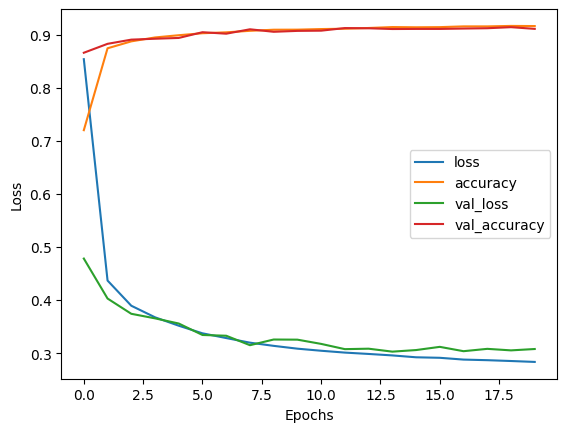

In [9]:
pd.DataFrame(base_model_mnist_loss.history).plot()
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

In [10]:
import itertools
from sklearn.metrics import confusion_matrix

In [11]:
def tf_confusion_matrix(y_true, y_pred, classes=None, figsize=(10, 10), text_size=15):
  cm = confusion_matrix(y_true, y_pred)
  cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]
  n_classes = cm.shape[0]

  fig, ax = plt.subplots(figsize=figsize)
  cax = ax.matshow(cm, cmap=plt.cm.Reds)
  fig.colorbar(cax)

  if classes:
    labels = classes
  else:
    labels = np.arange(cm.shape[0])

  ax.set(title="Tensorflow Confusion Matrix",
         xlabel="Predicted label",
         ylabel="True label",
         xticks=np.arange(n_classes),
         yticks=np.arange(n_classes),
         xticklabels=labels,
         yticklabels=labels)

  ax.xaxis.set_label_position("bottom")
  ax.xaxis.tick_bottom()

  threshold = (cm.max() + cm.min()) / 2.

  for i,j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, f"{cm[i,j]} ({cm_norm[i,j]*100:.1f}%)",
             horizontalalignment="center",
             color="white" if cm[i,j] > threshold else "black",
             size=text_size)

In [12]:
y_probs = base_model_mnist.predict(test_images)
y_preds = y_probs.argmax(axis=1)

313/313 [==============================] - 1s 3ms/step


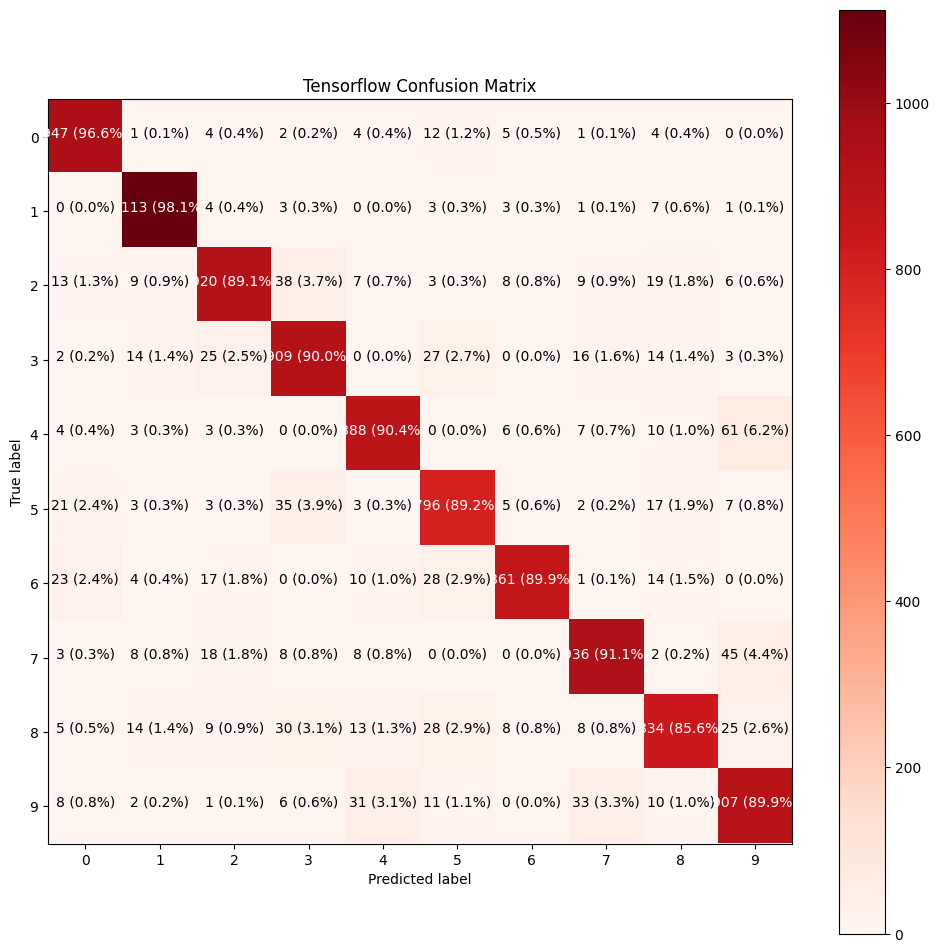

In [13]:
tf_confusion_matrix(test_labels, y_preds, classes=class_names, figsize=(12, 12), text_size=10)